# SNN Readout Study — CIFAR-10
Compares six SNN classifier readout strategies on CARSON routing.
All settings identical except the readout type.

In [1]:
import json
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

ROOT     = Path().resolve().parent.parent   # repo root
LOG_ROOT = ROOT / "logs" / "snn_readout_study"
OUT_DIR  = Path().resolve()
OUT_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", palette="tab10")
plt.rcParams.update({"figure.dpi": 140, "axes.titlesize": 11, "axes.labelsize": 10})

DATASET  = "cifar10"
VARIANTS = [
    "mean_membrane",
    "last_membrane",
    "mean_spikes",
    "spike_count",
    "membrane_spike_hybrid",
    "temporal_pool",
]
LABELS = {
    "mean_membrane":        "Mean membrane (μ)",
    "last_membrane":        "Last membrane (final step)",
    "mean_spikes":          "Mean spikes (spike rate)",
    "spike_count":          "Spike count",
    "membrane_spike_hybrid": "Membrane + spike hybrid",
    "temporal_pool":        "Temporal pool",
}
MAX_ENTROPY = math.log(2)   # log(num_groups=2)

def save(fig, name):
    path = OUT_DIR / f"{name}.png"
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print(f"saved → {path}")

In [2]:
# ── Load all variant runs ────────────────────────────────────────────────────
rows = []
for variant in VARIANTS:
    run_dir      = LOG_ROOT / variant / DATASET / "cats" / "carson" / "run_001"
    metrics_file = run_dir / "best_metrics.json"
    train_log    = run_dir / "train_log.csv"
    if not metrics_file.exists():
        print(f"MISSING: {metrics_file}")
        continue
    m = json.loads(metrics_file.read_text())
    v = m["val_metrics"]
    rows.append({
        "variant":    variant,
        "label":      LABELS[variant],
        "log_dir":    run_dir,
        "train_log":  train_log if train_log.exists() else None,
        "best_epoch": m["best_epoch"],
        "val_f1":     v["f1"],
        "val_acc":    v["accuracy"],
        "val_loss":   v["loss"],
        "spk_samp":   v.get("val_spikes_per_sample", float("nan")),
        "spk_tok":    v.get("val_spikes_per_token",  float("nan")),
        "firing_rate": v.get("val_firing_rate",      float("nan")),
        "exc_rate":   v.get("val_exc_firing_rate",   float("nan")),
        "inh_rate":   v.get("val_inh_firing_rate",   float("nan")),
        "entropy":    v.get("val_routing_entropy",   float("nan")),
        "routing_var": v.get("val_routing_variance", float("nan")),
        "dominance":  v.get("val_dominance_fraction",float("nan")),
        "collapsed":  v["f1"] < 0.05,
    })

df = pd.DataFrame(rows)
order_map = {v: i for i, v in enumerate(VARIANTS)}
df["_order"] = df["variant"].map(order_map)
df = df.sort_values("_order").reset_index(drop=True)

print(f"Loaded {len(df)} variant runs\n")
for _, row in df.iterrows():
    status = "COLLAPSED (near-random)" if row["collapsed"] else "OK"
    print(f"  {row['variant']:<26}  val_f1={row['val_f1']:.4f}  best_epoch={row['best_epoch']}  [{status}]")

Loaded 6 variant runs

  mean_membrane               val_f1=0.6734  best_epoch=8  [OK]
  last_membrane               val_f1=0.6715  best_epoch=7  [OK]
  mean_spikes                 val_f1=0.5925  best_epoch=10  [OK]
  spike_count                 val_f1=0.6519  best_epoch=7  [OK]
  membrane_spike_hybrid       val_f1=0.6575  best_epoch=9  [OK]
  temporal_pool               val_f1=0.6699  best_epoch=5  [OK]


## 1. Summary Table

In [3]:
display_cols = {
    "label":       "Readout",
    "val_f1":      "Val F1",
    "val_acc":     "Val Acc",
    "val_loss":    "Val Loss",
    "best_epoch":  "Best Ep.",
    "spk_samp":    "Spk/Samp",
    "spk_tok":     "Spk/Tok",
    "firing_rate": "Firing Rate",
    "exc_rate":    "Exc Rate",
    "inh_rate":    "Inh Rate",
    "entropy":     "H",
}
tbl = df[list(display_cols)].rename(columns=display_cols)
fmt = {
    "Val F1":      "{:.4f}",
    "Val Acc":     "{:.4f}",
    "Val Loss":    "{:.4f}",
    "Spk/Samp":    "{:.0f}",
    "Spk/Tok":     "{:.1f}",
    "Firing Rate": "{:.4f}",
    "Exc Rate":    "{:.4f}",
    "Inh Rate":    "{:.4f}",
    "H":           "{:.4f}",
}
tbl.style.format(fmt, na_rep="—") \
    .bar(subset=["Val F1"], align="left", color="#92c5de") \
    .apply(lambda col: ["background-color: #fddbc7" if df.iloc[i]["collapsed"] else ""
                        for i in range(len(df))], axis=0) \
    .set_caption("SNN readout study — CIFAR-10, CARSON routing  (orange = collapsed)")

,Readout,Val F1,Val Acc,Val Loss,Best Ep.,Spk/Samp,Spk/Tok,Firing Rate,Exc Rate,Inh Rate,H
0,Mean membrane (μ),0.6734,0.6734,1.0021,8,6255,96.2,0.3759,0.3807,0.3711,0.6893
1,Last membrane (final step),0.6715,0.6736,0.9670,7,4081,62.8,0.2453,0.2445,0.2460,0.6674
2,Mean spikes (spike rate),0.5925,0.6068,1.7417,10,6114,94.1,0.3675,0.3995,0.3354,0.6920
3,Spike count,0.6519,0.6488,1.3104,7,2928,45.0,0.1759,0.1662,0.1857,0.4382
4,Membrane + spike hybrid,0.6575,0.6600,1.0451,9,5259,80.9,0.3161,0.2978,0.3344,0.6887
5,Temporal pool,0.6699,0.6734,0.9370,5,5814,89.4,0.3494,0.3146,0.3843,0.6889


## 2. Val F1 Comparison

C:\Users\Zohoor Almalki\AppData\Local\Temp\ipykernel_12580\643598747.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df["label"], rotation=20, ha="right", fontsize=9)


saved → C:\Users\Zohoor Almalki\Projects\CATS\results\snn_readout_study\1_val_f1_comparison.png


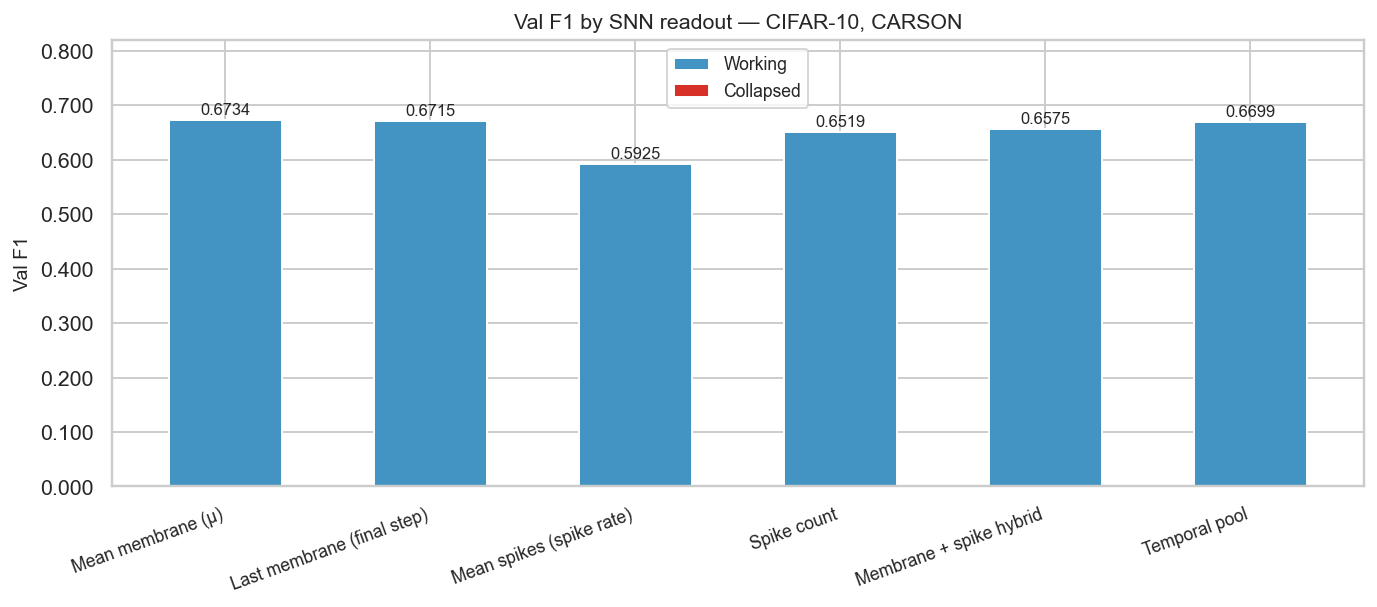

In [4]:
from matplotlib.patches import Patch

colors = ["#d73027" if row["collapsed"] else "#4393c3" for _, row in df.iterrows()]

fig, ax = plt.subplots(figsize=(10, 4.5))
bars = ax.bar(df["label"], df["val_f1"], color=colors, edgecolor="white", width=0.55)

for bar, val, (_, row) in zip(bars, df["val_f1"], df.iterrows()):
    label = f"{val:.4f}" if not row["collapsed"] else f"{val:.4f}\n(collapsed)"
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.004,
            label, ha="center", va="bottom", fontsize=8.5)

ax.set(ylabel="Val F1", title="Val F1 by SNN readout — CIFAR-10, CARSON")
ax.set_xticklabels(df["label"], rotation=20, ha="right", fontsize=9)
ax.set_ylim(0, 0.82)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))
ax.legend(handles=[
    Patch(facecolor="#4393c3", label="Working"),
    Patch(facecolor="#d73027", label="Collapsed"),
], fontsize=9)
fig.tight_layout()
save(fig, "1_val_f1_comparison")
plt.show()

## 3. Training Curves — Val F1 and Val Loss per Epoch

saved → C:\Users\Zohoor Almalki\Projects\CATS\results\snn_readout_study\2_training_curves.png


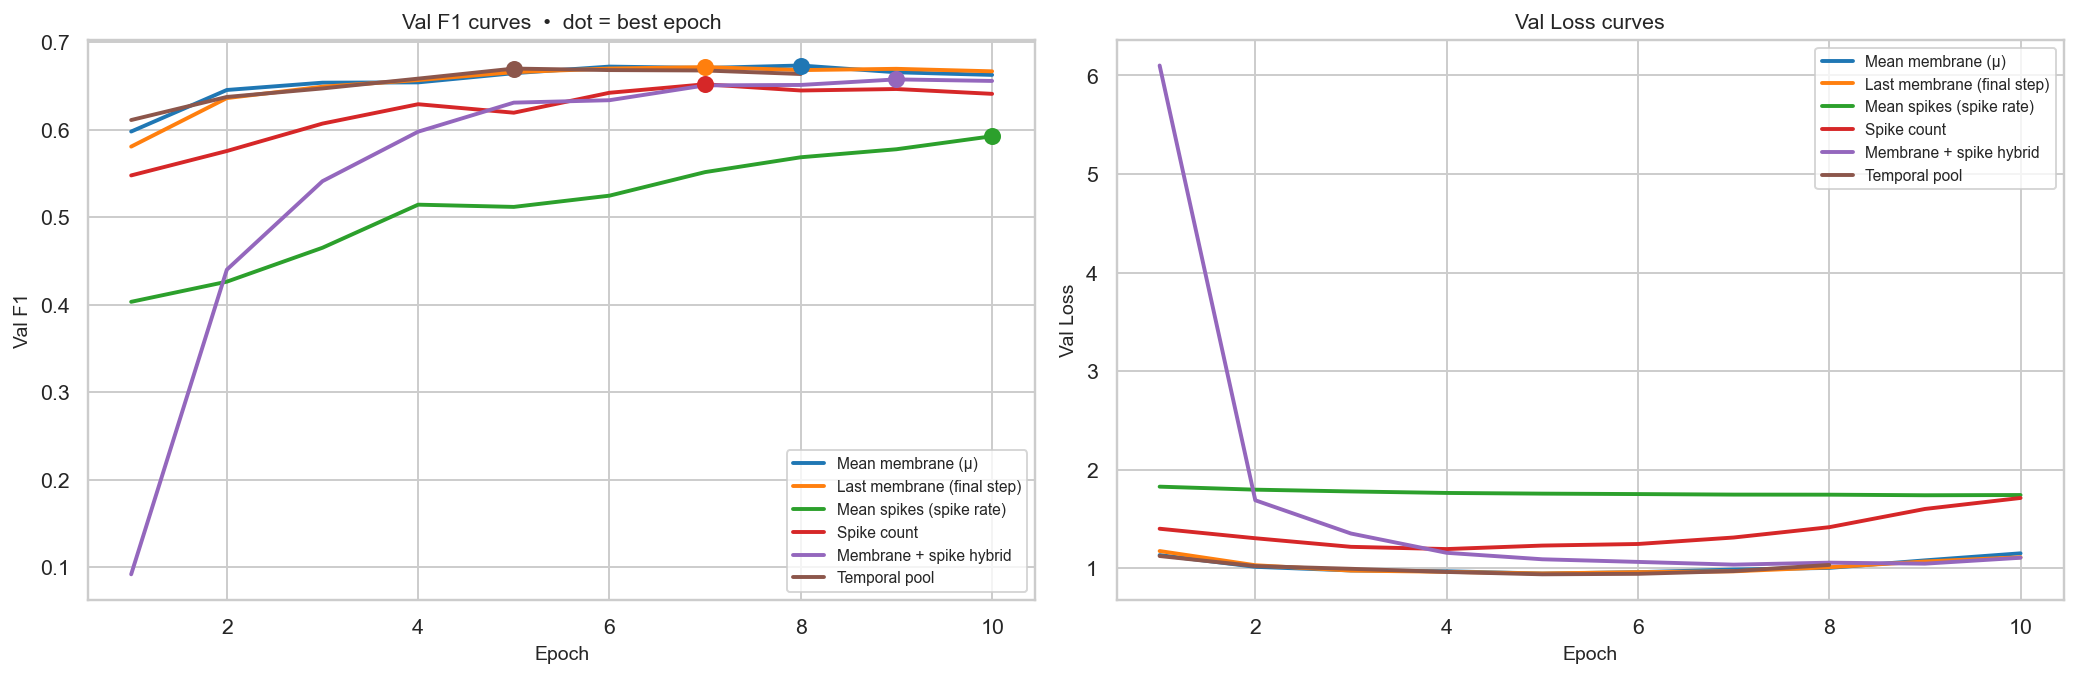

In [5]:
palette = sns.color_palette("tab10", n_colors=len(df))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for (_, row), color in zip(df.iterrows(), palette):
    if row["train_log"] is None:
        continue
    tl = pd.read_csv(row["train_log"])
    lw = 2.0 if not row["collapsed"] else 1.0
    ls = "-"  if not row["collapsed"] else "--"

    axes[0].plot(tl["epoch"], tl["val_f1"], label=row["label"],
                 color=color, linewidth=lw, linestyle=ls)
    best_f1 = tl.loc[tl["epoch"] == row["best_epoch"], "val_f1"]
    if not best_f1.empty:
        axes[0].scatter(row["best_epoch"], best_f1.values[0], color=color, s=60, zorder=5)

    axes[1].plot(tl["epoch"], tl["val_loss"], label=row["label"],
                 color=color, linewidth=lw, linestyle=ls)

axes[0].set(xlabel="Epoch", ylabel="Val F1",  title="Val F1 curves  •  dot = best epoch")
axes[1].set(xlabel="Epoch", ylabel="Val Loss", title="Val Loss curves")
for ax in axes:
    ax.legend(fontsize=8)
fig.tight_layout()
save(fig, "2_training_curves")
plt.show()

## 4. Spiking Efficiency (working variants only)
`mean_spikes` and `spike_count` excluded — collapsed runs have no meaningful spiking metrics.

saved → C:\Users\Zohoor Almalki\Projects\CATS\results\snn_readout_study\3_spiking_efficiency.png


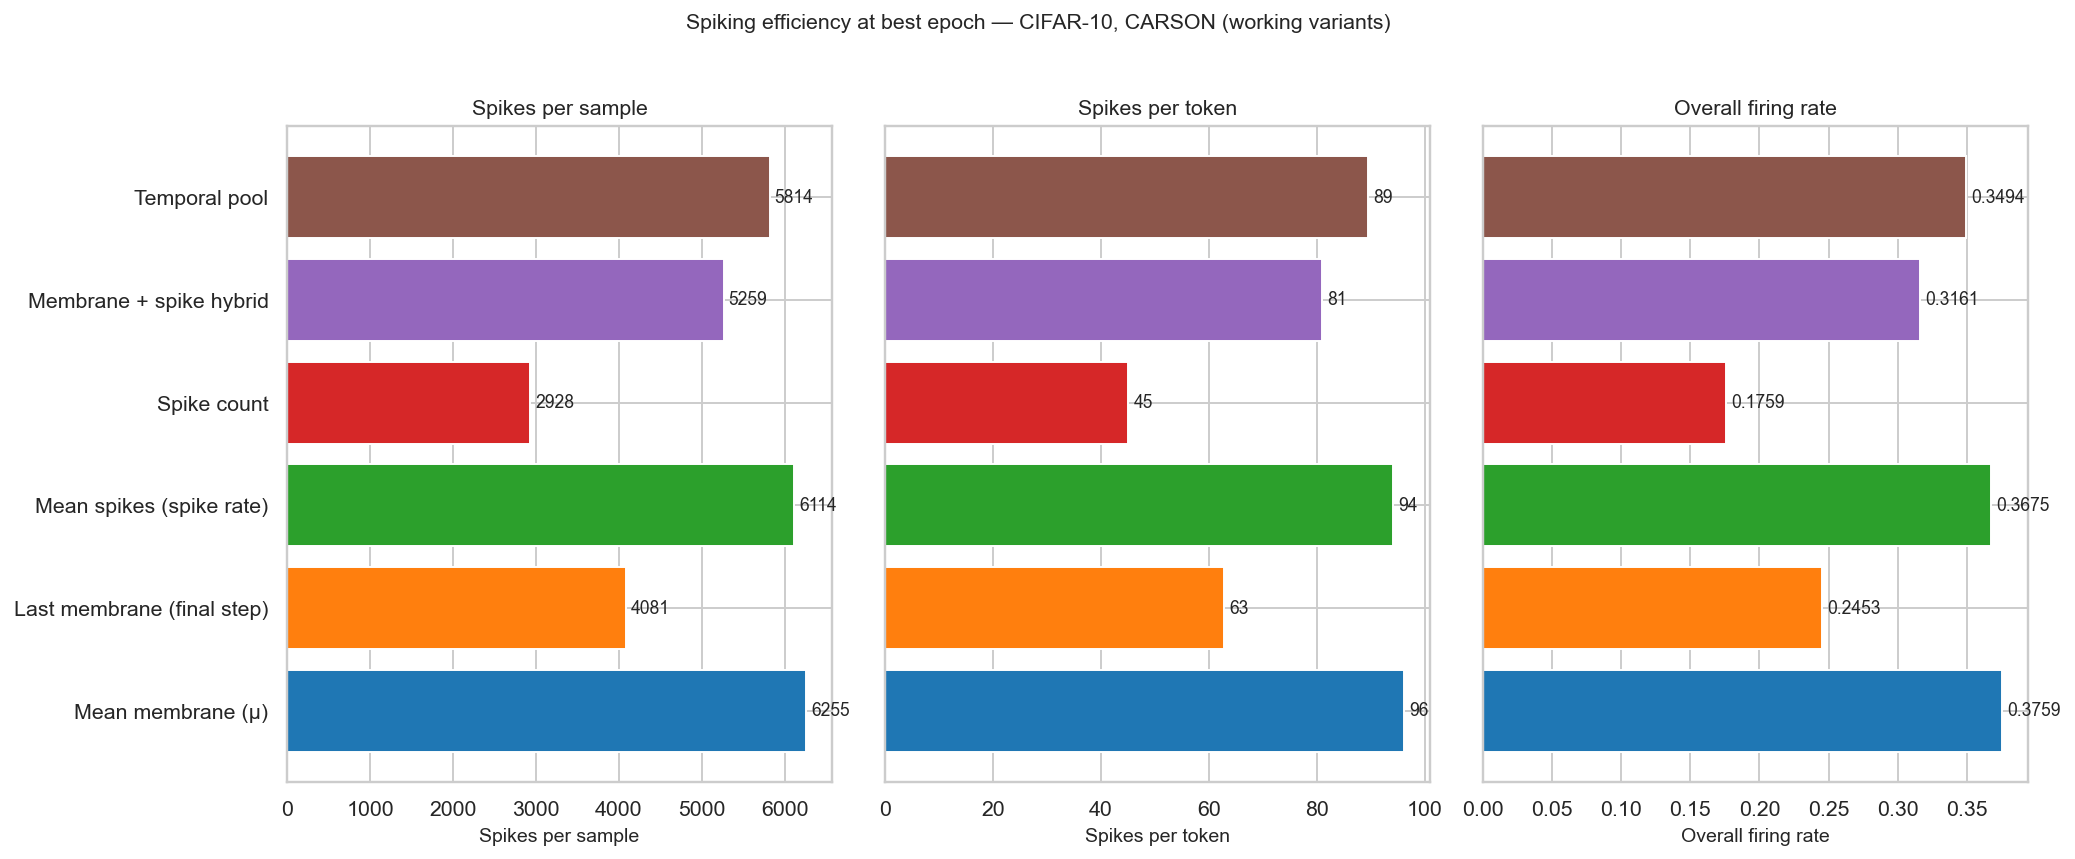

In [6]:
df_ok = df[~df["collapsed"]].copy().reset_index(drop=True)
palette_ok = sns.color_palette("tab10", n_colors=len(df))
colors_ok  = [palette_ok[i] for i in df[~df["collapsed"]].index]

fig, axes = plt.subplots(1, 3, figsize=(15, 0.7 * len(df_ok) + 1.8), sharey=True)
for ax, col, title in zip(
        axes,
        ["spk_samp", "spk_tok", "firing_rate"],
        ["Spikes per sample", "Spikes per token", "Overall firing rate"]):
    vals = df_ok[col]
    bars = ax.barh(df_ok["label"], vals, color=colors_ok, edgecolor="white")
    for bar, val in zip(bars, vals):
        fmt_str = f"{val:.4f}" if col == "firing_rate" else f"{val:.0f}"
        ax.text(val + vals.max() * 0.01, bar.get_y() + bar.get_height() / 2,
                fmt_str, va="center", fontsize=9)
    ax.set(xlabel=title, title=title)

fig.suptitle("Spiking efficiency at best epoch — CIFAR-10, CARSON (working variants)",
             y=1.02, fontsize=11)
fig.tight_layout()
save(fig, "3_spiking_efficiency")
plt.show()

## 5. Excitatory / Inhibitory Firing Rates

saved → C:\Users\Zohoor Almalki\Projects\CATS\results\snn_readout_study\4_exc_inh_rates.png


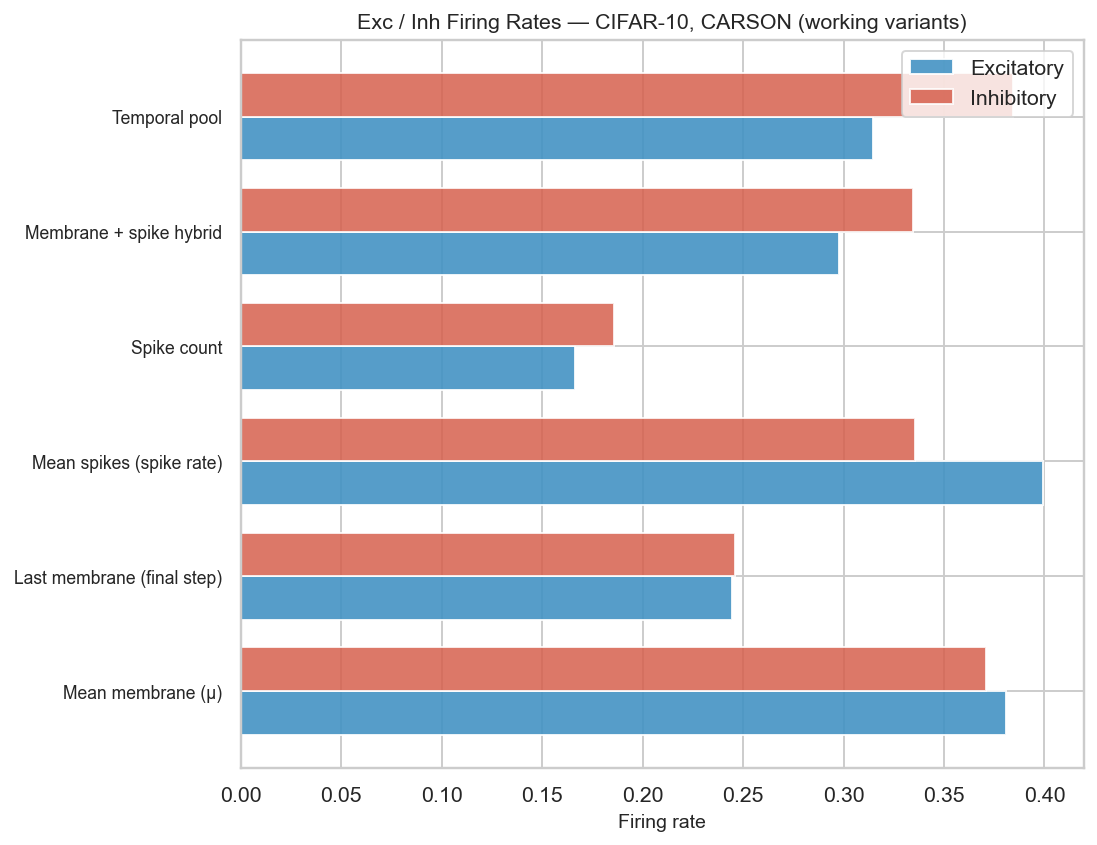

In [7]:
palette_all = sns.color_palette("tab10", n_colors=len(df))
y     = np.arange(len(df_ok))
width = 0.38

fig, ax = plt.subplots(figsize=(8, 0.7 * len(df_ok) + 2))
ax.barh(y - width/2, df_ok["exc_rate"], width, label="Excitatory", color="#4393c3", alpha=0.9)
ax.barh(y + width/2, df_ok["inh_rate"], width, label="Inhibitory", color="#d6604d", alpha=0.85)

ax.set_yticks(y)
ax.set_yticklabels(df_ok["label"], fontsize=9)
ax.set(xlabel="Firing rate",
       title="Exc / Inh Firing Rates — CIFAR-10, CARSON (working variants)")
ax.legend()
fig.tight_layout()
save(fig, "4_exc_inh_rates")
plt.show()

## 6. Routing Metrics

saved → C:\Users\Zohoor Almalki\Projects\CATS\results\snn_readout_study\5_routing_metrics.png


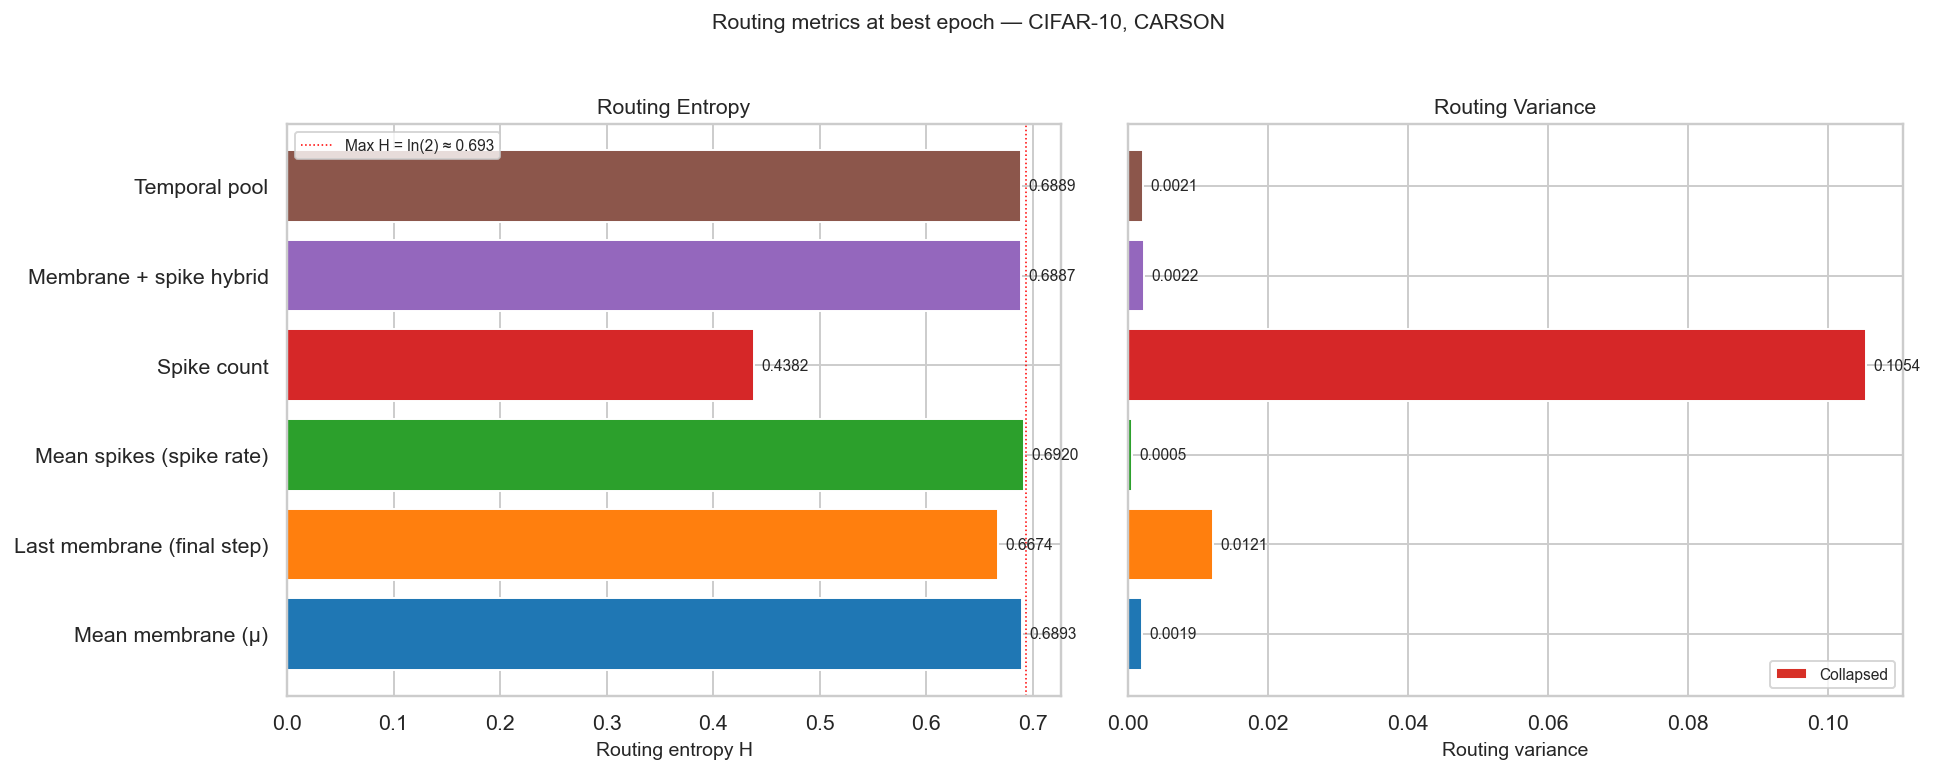

In [8]:
palette_all = sns.color_palette("tab10", n_colors=len(df))
colors_all  = ["#d73027" if row["collapsed"] else palette_all[i]
               for i, (_, row) in enumerate(df.iterrows())]

fig, axes = plt.subplots(1, 2, figsize=(14, 0.65 * len(df) + 1.5), sharey=True)
for ax, col, xlabel in zip(
        axes,
        ["entropy", "routing_var"],
        ["Routing entropy H", "Routing variance"]):
    vals = df[col]
    bars = ax.barh(df["label"], vals, color=colors_all, edgecolor="white")
    for bar, val in zip(bars, vals):
        ax.text(val + vals.max() * 0.01, bar.get_y() + bar.get_height() / 2,
                f"{val:.4f}", va="center", fontsize=8)
    ax.set(xlabel=xlabel)

axes[0].axvline(MAX_ENTROPY, color="red", linewidth=0.8, linestyle=":",
                label=f"Max H = ln(2) ≈ {MAX_ENTROPY:.3f}")
axes[0].legend(fontsize=8)
axes[0].set_title("Routing Entropy")
axes[1].set_title("Routing Variance")
from matplotlib.patches import Patch
axes[1].legend(handles=[
    Patch(facecolor="#d73027", label="Collapsed"),
], fontsize=8, loc="lower right")
fig.suptitle("Routing metrics at best epoch — CIFAR-10, CARSON", y=1.02, fontsize=11)
fig.tight_layout()
save(fig, "5_routing_metrics")
plt.show()

## 7. Working Variants — Full Training Dynamics

saved → C:\Users\Zohoor Almalki\Projects\CATS\results\snn_readout_study\7_working_variants_curves.png


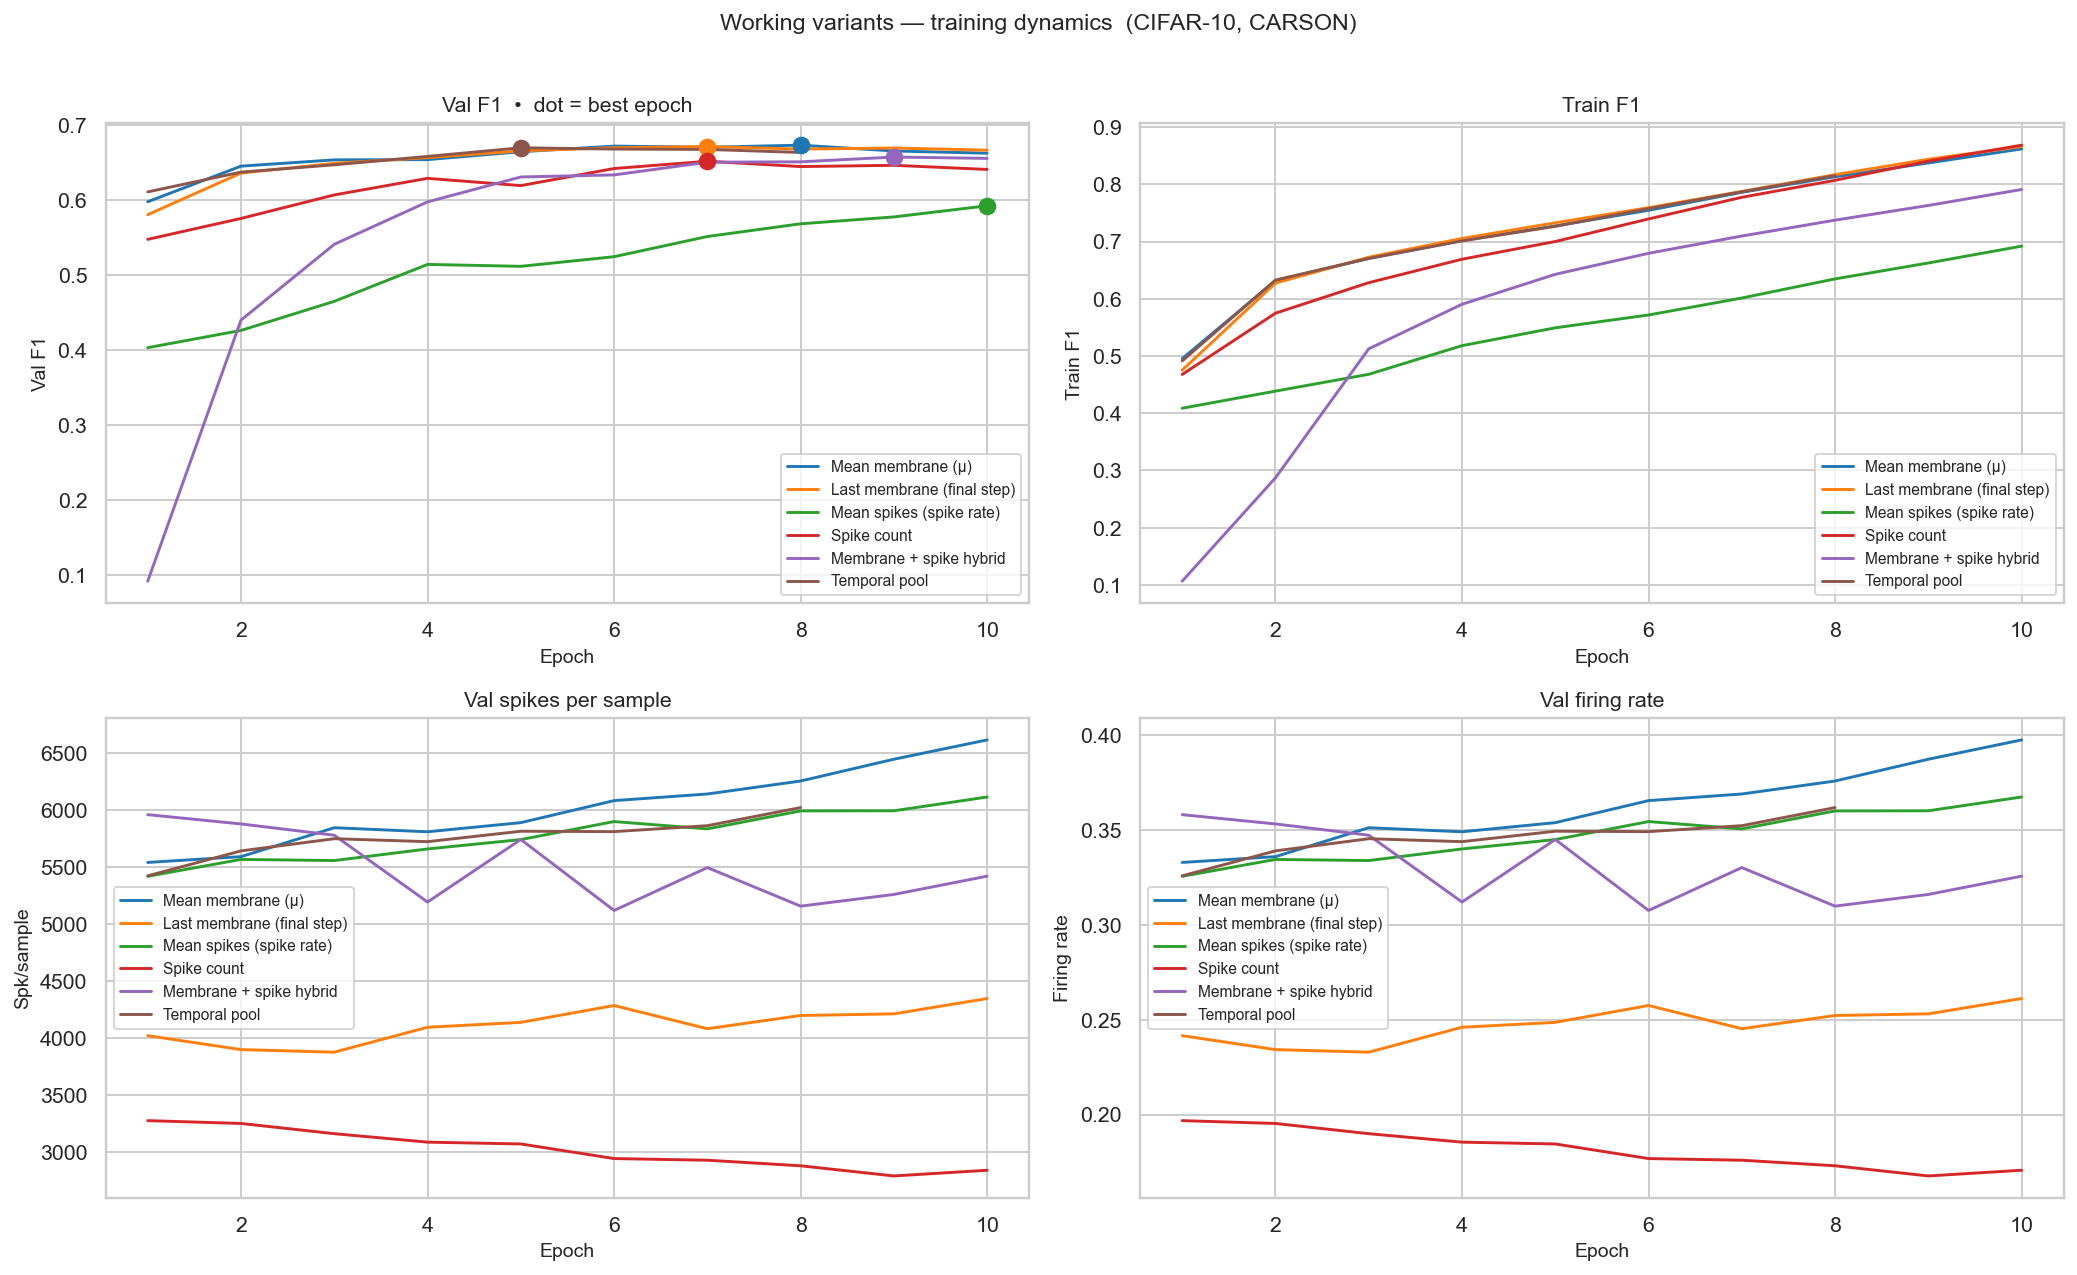

In [10]:
df_ok      = df[~df["collapsed"]].reset_index(drop=True)
palette_ok = sns.color_palette("tab10", n_colors=len(df_ok))

fig, axes = plt.subplots(2, 2, figsize=(15, 9))

for (_, row), color in zip(df_ok.iterrows(), palette_ok):
    tl = pd.read_csv(row["train_log"])

    axes[0,0].plot(tl["epoch"], tl["val_f1"],   label=row["label"], color=color)
    best_f1 = tl.loc[tl["epoch"] == row["best_epoch"], "val_f1"]
    if not best_f1.empty:
        axes[0,0].scatter(row["best_epoch"], best_f1.values[0], color=color, s=65, zorder=5)

    axes[0,1].plot(tl["epoch"], tl["train_f1"],             label=row["label"], color=color)
    axes[1,0].plot(tl["epoch"], tl["val_spikes_per_sample"], label=row["label"], color=color)
    axes[1,1].plot(tl["epoch"], tl["val_firing_rate"],       label=row["label"], color=color)

axes[0,0].set(xlabel="Epoch", ylabel="Val F1",     title="Val F1  •  dot = best epoch")
axes[0,1].set(xlabel="Epoch", ylabel="Train F1",   title="Train F1")
axes[1,0].set(xlabel="Epoch", ylabel="Spk/sample", title="Val spikes per sample")
axes[1,1].set(xlabel="Epoch", ylabel="Firing rate",title="Val firing rate")
for ax in axes.flat:
    ax.legend(fontsize=8)

fig.suptitle("Working variants — training dynamics  (CIFAR-10, CARSON)",
             fontsize=12, y=1.01)
fig.tight_layout()
save(fig, "7_working_variants_curves")
plt.show()

## 8. Comprehensive Metrics Heatmap (working variants)

saved → C:\Users\Zohoor Almalki\Projects\CATS\results\snn_readout_study\8_heatmap_working_variants.png


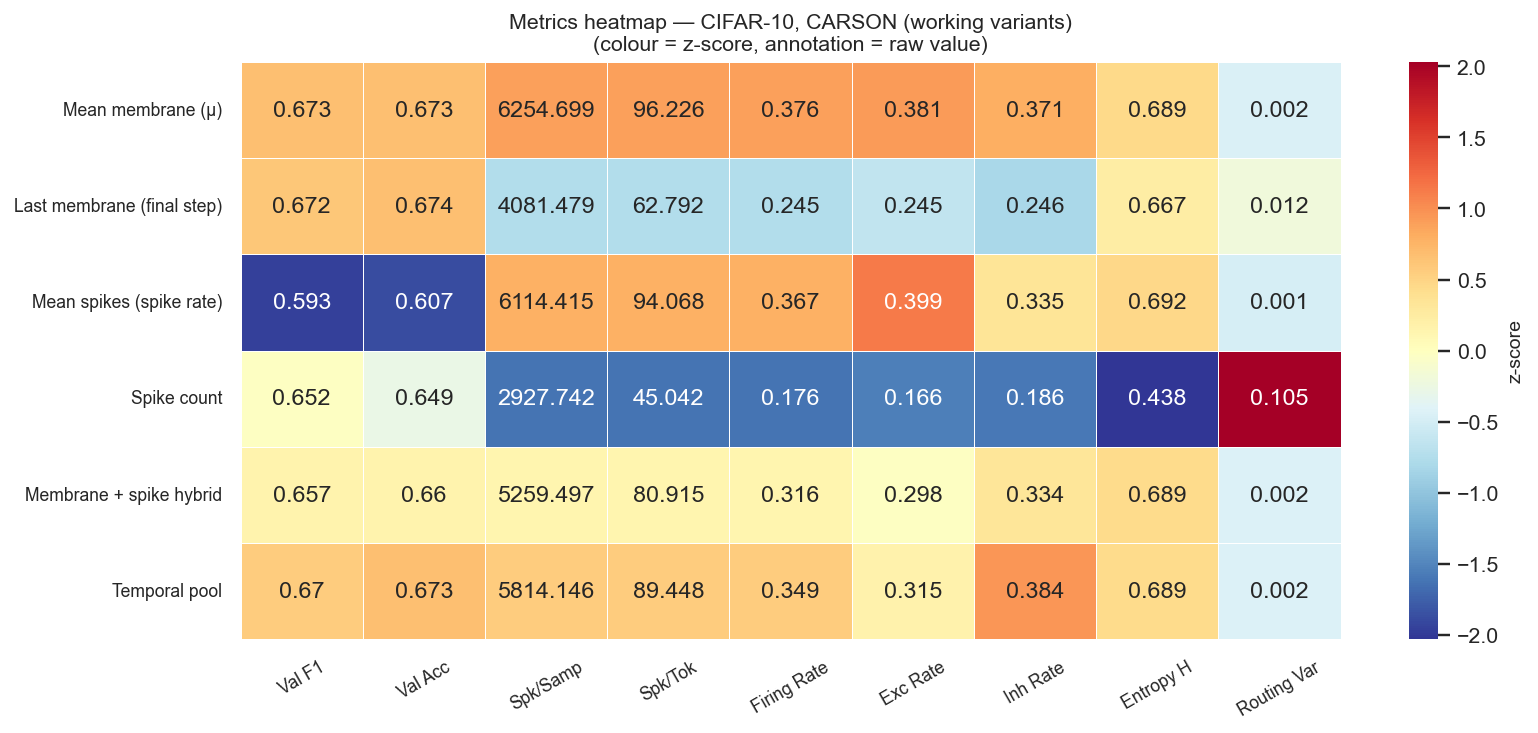

In [11]:
heat_cols = {
    "val_f1":      "Val F1",
    "val_acc":     "Val Acc",
    "spk_samp":    "Spk/Samp",
    "spk_tok":     "Spk/Tok",
    "firing_rate": "Firing Rate",
    "exc_rate":    "Exc Rate",
    "inh_rate":    "Inh Rate",
    "entropy":     "Entropy H",
    "routing_var": "Routing Var",
}
heat   = df_ok.set_index("label")[list(heat_cols)].rename(columns=heat_cols)
heat_z = heat.copy()
for col in heat_z.columns:
    col_vals = heat_z[col].dropna()
    if col_vals.std() > 0:
        heat_z[col] = (heat_z[col] - col_vals.mean()) / col_vals.std()

fig, ax = plt.subplots(figsize=(len(heat_cols) * 1.2 + 1, len(df_ok) * 0.65 + 1.5))
sns.heatmap(
    heat_z,
    ax=ax,
    annot=heat.round(3),
    fmt="",
    cmap="RdYlBu_r",
    center=0,
    linewidths=0.4,
    cbar_kws={"label": "z-score"},
)
ax.set(title="Metrics heatmap — CIFAR-10, CARSON (working variants)\n"
             "(colour = z-score, annotation = raw value)")
ax.set_ylabel("")
ax.tick_params(axis="x", rotation=30, labelsize=9)
ax.tick_params(axis="y", rotation=0,  labelsize=9)
fig.tight_layout()
save(fig, "8_heatmap_working_variants")
plt.show()